In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, auc, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("MODELO 1: LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

# Cargar datos procesados
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"\n✅ Datos cargados:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")

# Entrenar Logistic Regression
print(f"\n🔄 Entrenando Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predicciones
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
y_test_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]  # Probabilidades

print(f"✅ Modelo entrenado")

# Evaluación
print(f"\n📊 RESULTADOS - LOGISTIC REGRESSION:")
print(f"\nTrain Accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {lr_model.score(X_test, y_test):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba_lr):.4f}")

print(f"\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_lr, 
                           target_names=['Good Credit', 'Bad Credit']))

MODELO 1: LOGISTIC REGRESSION (BASELINE)

✅ Datos cargados:
   X_train: (800, 20)
   X_test: (200, 20)

🔄 Entrenando Logistic Regression...
✅ Modelo entrenado

📊 RESULTADOS - LOGISTIC REGRESSION:

Train Accuracy: 0.7750
Test Accuracy: 0.7650
Test ROC-AUC: 0.7880

Classification Report (Test):
              precision    recall  f1-score   support

 Good Credit       0.81      0.87      0.84       140
  Bad Credit       0.63      0.52      0.57        60

    accuracy                           0.77       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



In [2]:
import xgboost as xgb

print("\n" + "=" * 60)
print("MODELO 2: XGBOOST (AVANZADO)")
print("=" * 60)

# Entrenar XGBoost
print(f"\n🔄 Entrenando XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Predicciones
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"✅ Modelo entrenado")

# Evaluación
print(f"\n📊 RESULTADOS - XGBOOST:")
print(f"\nTrain Accuracy: {xgb_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {xgb_model.score(X_test, y_test):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba_xgb):.4f}")

print(f"\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_xgb,
                           target_names=['Good Credit', 'Bad Credit']))


MODELO 2: XGBOOST (AVANZADO)

🔄 Entrenando XGBoost...
✅ Modelo entrenado

📊 RESULTADOS - XGBOOST:

Train Accuracy: 0.9738
Test Accuracy: 0.7750
Test ROC-AUC: 0.8024

Classification Report (Test):
              precision    recall  f1-score   support

 Good Credit       0.80      0.90      0.85       140
  Bad Credit       0.67      0.48      0.56        60

    accuracy                           0.78       200
   macro avg       0.74      0.69      0.71       200
weighted avg       0.76      0.78      0.76       200



In [3]:
print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)

# Calcular métricas
lr_auc = roc_auc_score(y_test, y_test_pred_proba_lr)
xgb_auc = roc_auc_score(y_test, y_test_pred_proba_xgb)

lr_acc = lr_model.score(X_test, y_test)
xgb_acc = xgb_model.score(X_test, y_test)

# Crear tabla de comparación
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC'],
    'Logistic Regression': [f"{lr_acc:.4f}", f"{lr_auc:.4f}"],
    'XGBoost': [f"{xgb_acc:.4f}", f"{xgb_auc:.4f}"]
})

print("\n" + comparison.to_string(index=False))

# Determinar mejor modelo
if xgb_auc > lr_auc:
    print(f"\n🏆 GANADOR: XGBoost (ROC-AUC: {xgb_auc:.4f})")
    best_model = xgb_model
    best_proba = y_test_pred_proba_xgb
else:
    print(f"\n🏆 GANADOR: Logistic Regression (ROC-AUC: {lr_auc:.4f})")
    best_model = lr_model
    best_proba = y_test_pred_proba_lr


COMPARACIÓN DE MODELOS

  Metric Logistic Regression XGBoost
Accuracy              0.7650  0.7750
 ROC-AUC              0.7880  0.8024

🏆 GANADOR: XGBoost (ROC-AUC: 0.8024)


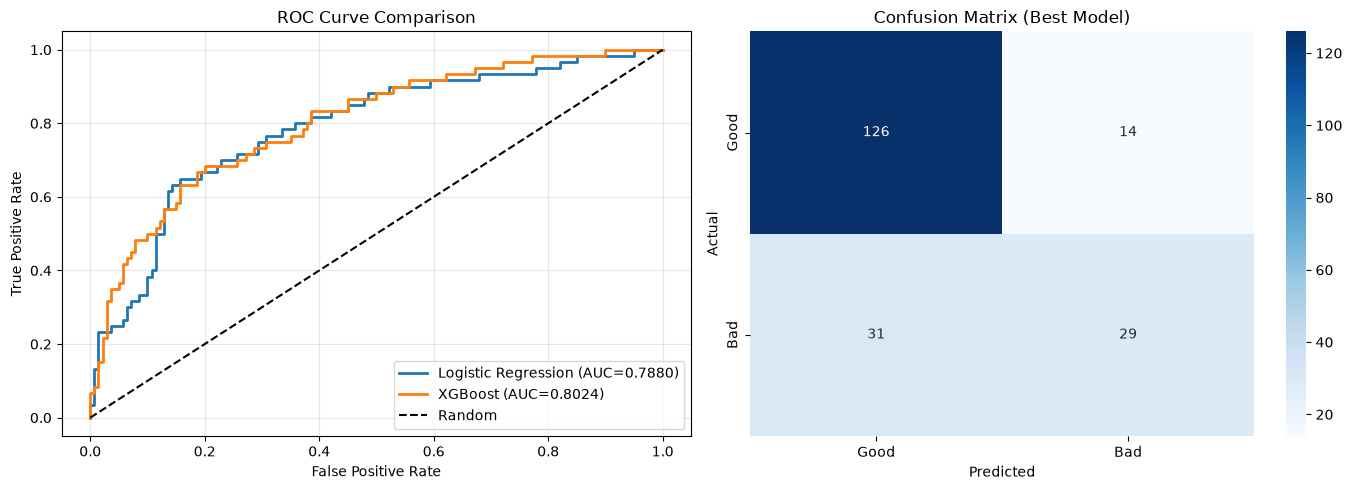

In [4]:
# Gráficos de ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_pred_proba_xgb)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.4f})', linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix for best model
if isinstance(best_model, xgb.XGBClassifier):
    y_pred_best = y_test_pred_xgb
else:
    y_pred_best = y_test_pred_lr

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
axes[1].set_title('Confusion Matrix (Best Model)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE (XGBOOST)

Top 10 características más importantes:
         Feature  Importance
   Credit_Amount       333.0
             Age       259.0
        Duration       194.0
         Purpose       147.0
      Employment       112.0
        Property        93.0
          Status        90.0
         Savings        83.0
Installment_Rate        74.0
  Credit_History        73.0


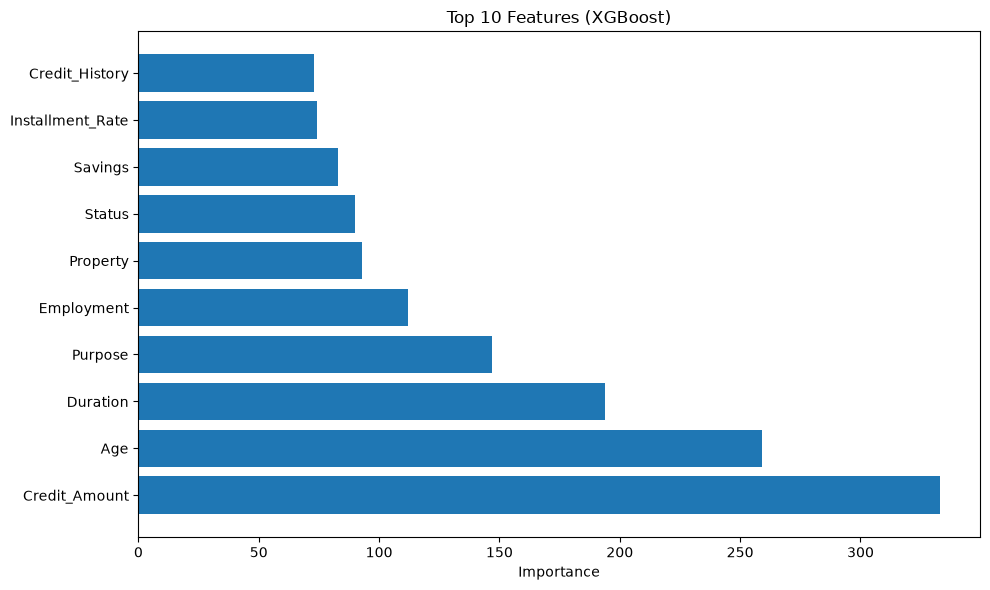

In [5]:
# Feature importance
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (XGBOOST)")
print("=" * 60)

importance = xgb_model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance.items()), 
    columns=['Feature', 'Importance']
).sort_values('Importance', ascending=False)

print("\nTop 10 características más importantes:")
print(importance_df.head(10).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features (XGBoost)')
plt.tight_layout()
plt.show()

In [6]:
import pickle
import os

os.makedirs("../results/models", exist_ok=True)

# Guardar modelos
with open("../results/models/logistic_regression.pkl", "wb") as f:
    pickle.dump(lr_model, f)

xgb_model.save_model("../results/models/xgboost_model.json")

print("✅ Modelos guardados:")
print("   - logistic_regression.pkl")
print("   - xgboost_model.json")

✅ Modelos guardados:
   - logistic_regression.pkl
   - xgboost_model.json
